# 📊 Customer Churn Analysis  
### Data Analyst Portfolio Project

This notebook analyzes customer churn behavior to uncover key drivers of attrition and identify actionable retention strategies.


In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

In [10]:
df = pd.read_csv("data/customer_churn_features.csv")
df.head()


,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,internet_service,contract,payment_method,monthly_charges,total_charges,churn,churn_flag,tenure_group,charge_bucket,high_risk
0,1,Female,0,Yes,No,5,Yes,Fiber optic,Month-to-month,Electronic check,75.3,376.5,Yes,1,0-12 months,Medium,0
1,2,Male,0,No,No,2,Yes,DSL,Month-to-month,Mailed check,55.1,110.2,No,0,0-12 months,Medium,0
2,3,Female,1,No,No,45,Yes,Fiber optic,Two year,Credit card,89.7,4036.2,No,0,24-48 months,High,0
3,4,Male,0,Yes,Yes,12,Yes,DSL,One year,Bank transfer,65.4,784.8,No,0,0-12 months,Medium,0
4,5,Female,0,No,No,1,Yes,Fiber optic,Month-to-month,Electronic check,99.2,99.2,Yes,1,0-12 months,High,1


In [7]:
import os
os.getcwd()


'c:\\Users\\misss\\Downloads\\Apply for Glory of JESUS CHRIST\\CUSTOMER-CHURN-ANALYSIS\\notebooks'

In [8]:
import os
os.chdir("c:/Users/misss/Downloads/Apply for Glory of JESUS CHRIST/CUSTOMER-CHURN-ANALYSIS")


In [9]:
os.getcwd()


'c:\\Users\\misss\\Downloads\\Apply for Glory of JESUS CHRIST\\CUSTOMER-CHURN-ANALYSIS'

## 📌 Dataset Overview

This dataset includes customer demographics, service usage, billing information, and churn labels.  
Feature engineering has added:
- `churn_flag`
- `tenure_group`
- `charge_bucket`
- `high_risk`


In [11]:
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       50 non-null     int64  
 1   gender            50 non-null     str    
 2   senior_citizen    50 non-null     int64  
 3   partner           50 non-null     str    
 4   dependents        50 non-null     str    
 5   tenure            50 non-null     int64  
 6   phone_service     50 non-null     str    
 7   internet_service  50 non-null     str    
 8   contract          50 non-null     str    
 9   payment_method    50 non-null     str    
 10  monthly_charges   50 non-null     float64
 11  total_charges     50 non-null     float64
 12  churn             50 non-null     str    
 13  churn_flag        50 non-null     int64  
 14  tenure_group      50 non-null     str    
 15  charge_bucket     50 non-null     str    
 16  high_risk         50 non-null     int64  
dtypes: float64

,customer_id,senior_citizen,tenure,monthly_charges,total_charges,churn_flag,high_risk
count,50.00000,50.000000,50.00000,50.000000,50.000000,50.000000,50.00000
mean,25.50000,0.320000,20.18000,74.820000,1473.374000,0.320000,0.30000
std,14.57738,0.471212,18.98731,21.243727,1437.587405,0.471212,0.46291
min,1.00000,0.000000,1.00000,43.900000,87.800000,0.000000,0.00000
25%,13.25000,0.000000,5.25000,55.250000,382.175000,0.000000,0.00000
50%,25.50000,0.000000,12.00000,79.100000,910.950000,0.000000,0.00000
75%,37.75000,1.000000,37.50000,96.225000,2401.400000,1.000000,1.00000
max,50.00000,1.000000,60.00000,104.300000,5526.000000,1.000000,1.00000


In [12]:
churn_rate = df["churn_flag"].mean()
print(f"Overall Churn Rate: {churn_rate:.2%}")

Overall Churn Rate: 32.00%


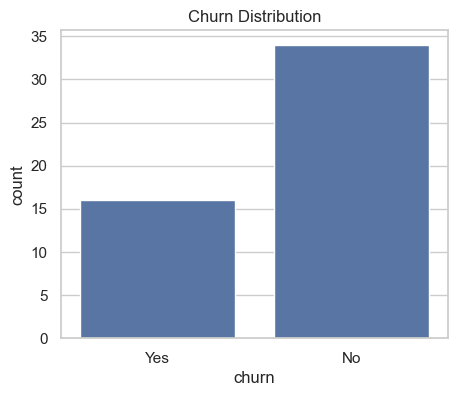

In [13]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="churn")
plt.title("Churn Distribution")
plt.savefig("visuals/churn_rate.png")
plt.show()


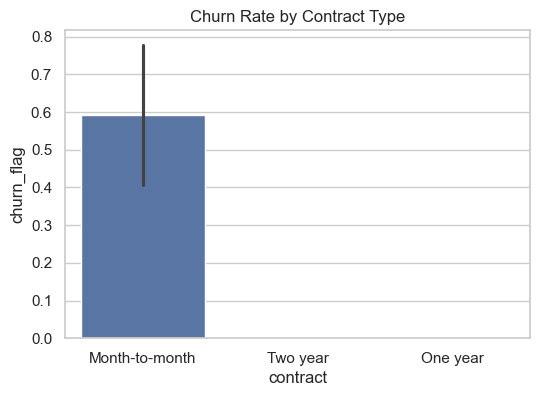

In [14]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="contract", y="churn_flag")
plt.title("Churn Rate by Contract Type")
plt.savefig("visuals/churn_by_contract.png")
plt.show()


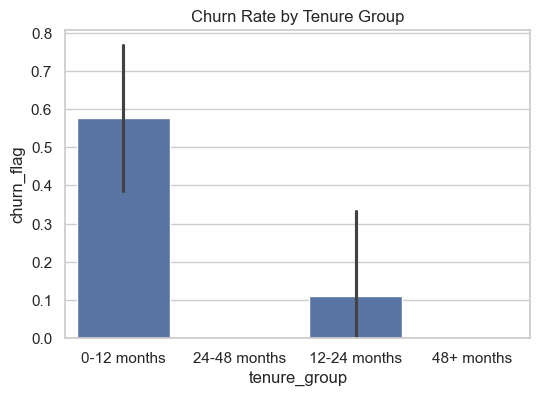

In [15]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="tenure_group", y="churn_flag")
plt.title("Churn Rate by Tenure Group")
plt.savefig("visuals/churn_by_tenure.png")
plt.show()


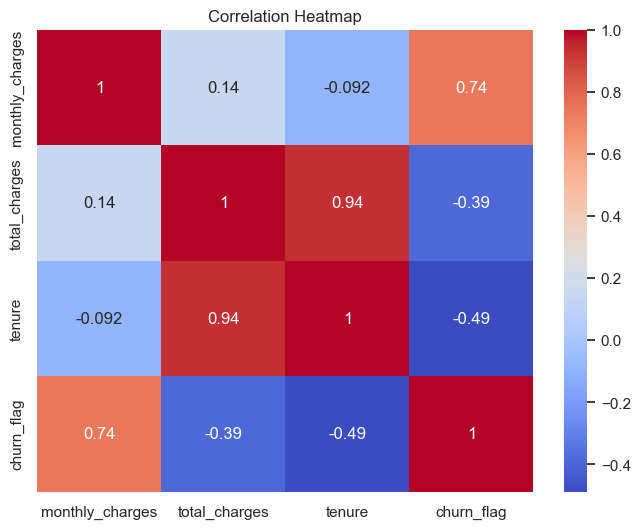

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["monthly_charges", "total_charges", "tenure", "churn_flag"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("visuals/churn_heatmap.png")
plt.show()


In [17]:
high_risk = df[df["high_risk"] == 1]
high_risk.head()


,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,internet_service,contract,payment_method,monthly_charges,total_charges,churn,churn_flag,tenure_group,charge_bucket,high_risk
4,5,Female,0,No,No,1,Yes,Fiber optic,Month-to-month,Electronic check,99.2,99.2,Yes,1,0-12 months,High,1
7,8,Male,0,No,No,3,Yes,Fiber optic,Month-to-month,Electronic check,92.4,277.2,Yes,1,0-12 months,High,1
9,10,Male,0,Yes,Yes,10,Yes,Fiber optic,Month-to-month,Electronic check,98.7,987.0,Yes,1,0-12 months,High,1
13,14,Male,0,No,No,6,Yes,Fiber optic,Month-to-month,Electronic check,95.4,572.4,Yes,1,0-12 months,High,1
16,17,Female,0,No,No,1,Yes,Fiber optic,Month-to-month,Electronic check,104.3,104.3,Yes,1,0-12 months,High,1


# 💡 Key Insights

### 1. Contract Type  
Month‑to‑month customers churn the most, indicating low commitment and high switching behavior.

### 2. Tenure  
Churn drops sharply after 12 months — early retention efforts are critical.

### 3. Monthly Charges  
Higher monthly charges correlate with higher churn, suggesting pricing sensitivity.

### 4. High‑Risk Segment  
Customers with high charges **and** churn history form a clear high‑risk group for targeted retention campaigns.
